## MODELING (KNN IMPUTATION VERSION)

In this notebook I will carry out Multilabel Classification on the knn-imputed version of the original dataset. Specifically, the classifiers I've decided to put to test are the followings: Logistic Regression, XGBoost, Random Forest, SVM, and Multilabel KNN. 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

#adding the parent directory to the system path to import the custom module
sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils.ml_stratifiers import MultilabelStratifiedShuffleSplit

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from scipy.stats import randint, loguniform
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

First of all, it is better to display the most important information about the knn-imputed dataset.  

In [3]:
file_path = r'C:\unibo-dtm-ml-2526-cervical-cancer-predictor\data\data_after_imputation\knn_imputed.csv'
df = pd.read_csv(file_path)

# repeat the data profiling pipeline for the newly cleaned data
df = pd.read_csv(file_path)

print("\nDataset Info: \n")
print(df.info())

#check whether everything went smoothly at the data cleaning stage
print("\nMissing Values: \n")
print(df.isnull().sum()) 


print("\nDescriptive Statistics:")
print(df.describe(include='all'))



Dataset Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              835 non-null    int64  
 1   Number of sexual partners        835 non-null    int64  
 2   First sexual intercourse         835 non-null    int64  
 3   Num of pregnancies               835 non-null    int64  
 4   Smokes (years)                   835 non-null    float64
 5   Smokes (packs/year)              835 non-null    float64
 6   Hormonal Contraceptives (years)  835 non-null    float64
 7   IUD (years)                      835 non-null    float64
 8   STDs (number)                    835 non-null    int64  
 9   STDs: Viral group                835 non-null    int64  
 10  STDs: Bacterial group            835 non-null    int64  
 11  STDs:condylomatosis              835 non-null    int64  
 12  STDs:

### HOW THE TRAINING & TESTING PROCESS WILL BE CARRIED OUT

Given the high data imbalance of the dataset, using a simple holdout method would've not been enough to ensure an ideal representativeness. That's why I opted for 5-folds Cross Validation, with each fold being filled according to a Multistratified Shuffle Split. 

In [4]:
#separating the targets from the other features
targets = ['Biopsy', 'Hinselmann', 'Schiller', 'Citology']
y = df[targets]
X = df.drop(columns=targets)

"""use msss (MultilabelStratifiedShuffleSplit) to split the data into train and test sets, 
ensuring that the distribution of the target variables is preserved in both sets.
This is particularly important in multilabel classification problems, where each instance can belong to multiple classes simultaneously.
Furthermore, this form of data splitting is needed for such an imbalanced dataset, where some classes may be underrepresented. 
"""

msss = MultilabelStratifiedShuffleSplit(n_splits=5, test_size=0.2,random_state=0)
msss.get_n_splits(X, y)

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"Training samples: {X_train.shape[0]} ({len(y_train[y_train.sum(axis=1) > 0])} with at least one positive target)")
print(f"Testing samples:  {X_test.shape[0]} ({len(y_test[y_test.sum(axis=1) > 0])} with at least one positive target)")

X_train: (668, 19)
X_test: (167, 19)
y_train: (668, 4)
y_test: (167, 4)
Training samples: 668 (80 with at least one positive target)
Testing samples:  167 (21 with at least one positive target)


### LOGISTIC REGRESSION

Attempt to find a single straight line that separates the healthy patients from the at risk ones. 

In [5]:
#enveloping the classifier in a MultiOutputClassifier that fits one independent classifier for each variable
#the four targets are treated as separate binary problems
ovr_clf = MultiOutputClassifier(LogisticRegression(class_weight='balanced', random_state=42),n_jobs=-1)

all_logR_reports = []

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    ovr_clf.fit(X_train, y_train)
    y_pred = ovr_clf.predict(X_test)
    
    """generating precision, recall, and F1-score for each target
    zero_division=0 prevents the code from crashing if a fold has zero prediced or actual positives for a rare target
    results are stored as a python dictionary so to be stored, and averaged later
    """
    report_dict = classification_report(y_test, y_pred, target_names=targets, zero_division=0, output_dict=True)
    all_logR_reports.append(report_dict)
    
#calculate the average precision, recall, and f1-score for each target across all folds
logR_final_results = {}

#macro avg calculates the average of the four targets without weighting them by their size
for target in targets + ['macro avg']:
    logR_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_logR_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_logR_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_logR_reports])
    }

#display the final results in a DataFrame for better readability

print("=== LOGISTIC REGRESSION FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(logR_final_results).T.round(3))


=== LOGISTIC REGRESSION FINAL AVERAGE PERFORMANCE (5-FOLDS) ===
            precision  recall  f1-score
Biopsy          0.180   0.600     0.277
Hinselmann      0.057   0.400     0.100
Schiller        0.189   0.533     0.279
Citology        0.084   0.467     0.142
macro avg       0.128   0.500     0.199


As likely expected, the result is not exceptional. The reasons behind this performance are mainly two: 
- the relationships between the various features is clearly non-linear, thus it cannot be represented by a straight line;
- the heavy data-imbalance of the dataset caused the model to set the line too leaned towards the healthy side. 

### XGBOOST

ExtremeGradientBoosting is an ensemble classifier that builds trees (like Random Forest), but is a sequential order, with each tree focusing on correcting the errors of the previous one. 

In [6]:
#set up a continuous parameter grid to explore a wider range of hyperparameters
random_grid = {
    'estimator__scale_pos_weight': randint(1, 6), #boosting the minority class
    'estimator__max_depth': randint(2, 6),    #depth of the trees    
    'estimator__learning_rate': loguniform(0.01, 0.1), #the search is made more granular at smaller values
    'estimator__n_estimators': randint(100, 600),
    'estimator__reg_lambda': loguniform(1, 100)   
}

xgb_estimator = xgb.XGBClassifier(
    objective='binary:logistic', #define the loss function to be minimized during training
    random_state=42 #reproducibility
)

multilabel_model = MultiOutputClassifier(xgb_estimator, n_jobs=-1)

xgb_random = RandomizedSearchCV(
    estimator=multilabel_model,
    param_distributions=random_grid, 
    n_iter=30, #30 iterations for a more thorough search, means picking 30 random combinations
    cv=3, #3-fold cross-validation for better generalization
    verbose=1, #verbose output to track progress
    random_state=42,
    scoring='average_precision', #optimize for average precision to better handle class imbalance
    n_jobs=-1
)

#list storing results for each of the five folds, to be averaged at the end for a more robust performance estimate
all_xgb_reports = []

#dynamic cross-validation loop with dynamic thresholding to optimize for recall >= 0.60 for each target
for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    xgb_random.fit(X_train, y_train)
    y_probs_list = xgb_random.predict_proba(X_test)

    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    y_pred = np.zeros_like(prob_matrix)
    
    # Dynamically find the best threshold for EACH target to hit your 0.6 Recall goal
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        # Lock Recall at >= 0.60
        valid_indices = np.where(recalls >= 0.60)[0]
        
        if len(valid_indices) > 0:
            best_index = valid_indices[np.argmax(precisions[valid_indices])]
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 # Softer clinical fallback
            
        y_pred[:, i] = (target_probs >= best_threshold).astype(int)
    
    report_dict = classification_report(y_test, y_pred, target_names=targets, zero_division=0, output_dict=True)
    all_xgb_reports.append(report_dict)

print("Best Parameters:", xgb_random.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'estimator__learning_rate': np.float64(0.03488960745139221), 'estimator__max_depth': 2, 'estimator__n_estimators': 256, 'estimator__reg_lambda': np.float64(40.215545266902886), 'estimator__scale_pos_weight': 1}


In [7]:
xgb_final_results = {}
for target in targets + ['macro avg']:
    xgb_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_xgb_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_xgb_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_xgb_reports])
    }
    
print("=== XGBOOST FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(xgb_final_results).T.round(3))

=== XGBOOST FINAL AVERAGE PERFORMANCE (5-FOLDS) ===
            precision  recall  f1-score
Biopsy          0.200   0.655     0.288
Hinselmann      0.068   0.829     0.126
Schiller        0.174   0.627     0.261
Citology        0.078   0.756     0.141
macro avg       0.130   0.716     0.204


The result is something to take into consideration. Also this model fails at reaching the 0.2 threshold for precision, but it compensates this behaviour with considerable outcomes in terms of recall. By iteratively focusing on the hardest-to-classify patients rather than just averaging random guesses, XGBoost was able to carve out much tighter "boxes" around the at-risk patients. 

In light of this performance, let's see how the various features contributed to influence the classifier's decision boundaries

<Figure size 1000x800 with 0 Axes>

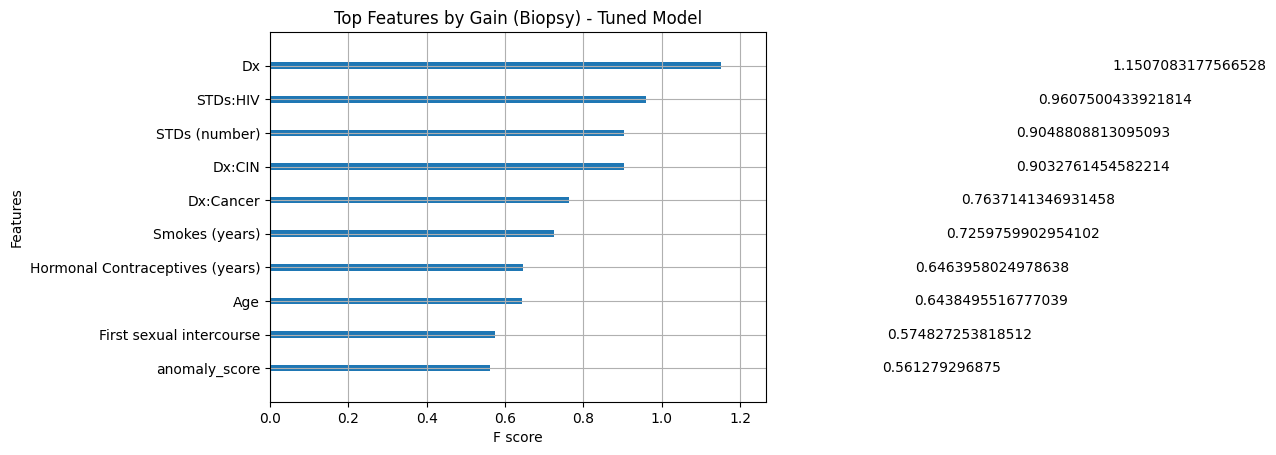

In [8]:
#feature importance for the biopsy target in the best fitted model
best_fitted_multilabel = xgb_random.best_estimator_
biopsy_estimator = best_fitted_multilabel.estimators_[0]

plt.figure(figsize=(10, 8))
xgb.plot_importance(biopsy_estimator, importance_type='gain', max_num_features=10)
plt.title("Top Features by Gain (Biopsy) - Tuned Model")
plt.show()

### RANDOM FOREST

Differently from XGBoost, Random Forest builds hundreds (500 in this case) of independent decision trees, each drawing "box-like" rules, and averages their votes. 

In [9]:
random_grid_rf = {
    'n_estimators': [100, 200, 500, 800], #n of trees utilized
    'max_depth': [3, 5, 8, 10, None], #complexity of a tree
    'min_samples_split': [2, 5, 10],  #minimum number of patients in a node, beyond which splitting is not admissible to prevent overfitting
    'min_samples_leaf': [1, 2, 4],   #minimum number of patients in end-nodes (leaves) 
    'max_features': ['sqrt', 'log2'],  #control the randomness in the RF: when deciding the split, the model can only look at a random subset of features
    'criterion': ['gini', 'entropy', 'log_loss'], #to evaluate split quality
    'bootstrap': [True, False],  #patient samples can be either drawn with replacement, or not      
    'class_weight': ['balanced', 'balanced_subsample']
}

forest_cls = RandomForestClassifier(criterion="entropy",
                                    n_estimators=500,
                                    class_weight='balanced_subsample', 
                                    random_state=42) # initialize the model

#telling RandomizedSearchCV to apply the parameters through the MultiOutputClassifier wrapper
rf_param_dist = {f'estimator__{k}': v for k, v in random_grid_rf.items()}

rf_random = RandomizedSearchCV(
    estimator=MultiOutputClassifier(forest_cls, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10, 
    cv=3, 
    scoring='average_precision', #search for parameters that maximize the area under the precision-recall curve
    verbose=1, 
    n_jobs=-1,
    random_state=42
)

all_rf_reports = []

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf_random.fit(X_train, y_train) 

    #list where each element is an array for each target
    y_probs_list = rf_random.predict_proba(X_test)

    """list comprehension that extracts the probability of the positive class for each target
    #np.transpose is used to reshape it into a standard matrix having 
        rows --> patients 
        columns --> medical targets
    """
    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    
    #generates a numpy array of the same dimensions as prob_matrix, filled with zeros
    #it will hold the final binary predictions
    y_pred = np.zeros_like(prob_matrix)
    
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        """discard any threshold that would result in missing more than 40% of positive cases
        to do so, create a boolean array, and have np.where extract the exact numerical indices of the True values
        """
        valid_indices = np.where(recalls >= 0.60)[0] #the 0 index pulls the array out of np.where's tuple output
        
        if len(valid_indices) > 0:
            #find the best thresholds within the "safe zone" (i.e., having recall >= 0.60)
            best_index = valid_indices[np.argmax(precisions[valid_indices])] #map the posiition back to the original index number of the full arrays
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 #default to high sensitivity if impossible to do better
            
        #the previously defined array of zeros is filled with the probabilities for each patient of belonging to each target
        y_pred[:, i] = (target_probs >= best_threshold).astype(int)
    
report_dict = classification_report(y_test, y_pred, target_names=targets, zero_division=0, output_dict=True)
all_rf_reports.append(report_dict)

print("Best parameters:", rf_random.best_params_)    

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

In [ ]:
rforest_final_results = {}
for target in targets + ['macro avg']:
    rforest_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_rf_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_rf_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_rf_reports])
    }
    
print("=== RANDOM FOREST FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(rforest_final_results).T.round(3))

The result is disappointing: the model was not able to properly adapt to the high imbalanced data, and therefore it "panicked" and tried to generate a global rule that aimed at minimizing the TP rate. It is not random that such behaviour is more evident for the Citology and Hinselmann's tests: both these two targets are characterized by very few positive values with respect to the totality. It was difficult for the model to provide a significative level of precision in these cases, especially if there's really too few positive cases to create decision boundaries upon. 

In [ ]:
biopsy_forest = rf_random.best_estimator_.estimators_[0] 

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(biopsy_forest.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title("Top 10 Clinical Features Driving High-Recall (Biopsy)")
plt.xlabel("Importance (Log Loss Reduction)")
plt.gca().invert_yaxis()
plt.show()

### SVM

SVM's Support Vector Classifier attempts to draw wide "margins" between classes, using curves (the kernels) to separate clusters. 

In [ ]:
param_grid = {
    'estimator__estimator__kernel': ['linear', 'poly', 'rbf', 'sigmoid'], #dictates the shape of the mathematical boundary separating sick and healthy patients
    'estimator__estimator__degree': [2, 3, 4], # Only for 'poly' kernel
    'estimator__estimator__C': [0.01, 0.1, 1, 10], #regularization parameter to control boundary "strictness"
    'estimator__estimator__gamma': ['scale', 'auto'], #how far the influence of a single training example reaches
}

#forcing the SVC to reason in terms of probability, not distance
svc = SVC(probability=True, class_weight='balanced')

"""wrapping the SVC model in MultiOutputRegressor, which is also wrapped around a Pipeline
the pipeline ensures features are scaled first, before being fed to the inner wrapper.
That's why we see "estimator__estimator__"
"""
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('estimator', MultiOutputClassifier(svc))
])

all_svc_reports = []

random_svc = RandomizedSearchCV(estimator=pipeline, 
                           param_distributions=param_grid,
                           n_iter=30, 
                           cv=3, 
                           verbose=2, 
                           n_jobs=-1, 
                           scoring='average_precision',
                           random_state=42
                           )

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    random_svc.fit(X_train, y_train)

    y_probs_list = random_svc.predict_proba(X_test)

    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    y_pred_svc = np.zeros_like(prob_matrix)
    
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        # Lock Recall at >= 0.60
        valid_indices = np.where(recalls >= 0.60)[0]
        
        if len(valid_indices) > 0:
            best_index = valid_indices[np.argmax(precisions[valid_indices])]
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 # Softer clinical fallback
            
        y_pred_svc[:, i] = (target_probs >= best_threshold).astype(int)
    report_dict = classification_report(y_test, y_pred_svc, target_names=targets, zero_division=0, output_dict=True)
    all_svc_reports.append(report_dict)

print("Best Parameters:", random_svc.best_params_)

In [ ]:
svc_final_results = {}
for target in targets + ['macro avg']:
    svc_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_svc_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_svc_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_svc_reports])
    }
    
print("=== SVC FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(svc_final_results).T.round(3))

Performance was decent, but the model failed (even if of a very small inch) to meet the precision threshold, and this is likely due to the fact that, because of high overlappings between the data clusters (i.e., healthy patients and sick patients were often caught together), the model created boundaries that were so wide that they swallowed up a huge number of healthy patients. Again, these results are particularly evident in the lowly-represented targets (Hinselmann and Citology), while the other two tests are characterized by kind of satisfying results. 

### MULTILABEL KNN


Differently from all the previous models, KNN is a "lazy learner", meaning that it does not build a global model, but rather it memorizes the dataset and checks the k closest patients to whatever new patient it is evaluating. 

In [ ]:
param_grid = {
    'estimator__estimator__n_neighbors': [9, 11, 29], 
    'estimator__estimator__weights': ['uniform', 'distance'],
    'estimator__estimator__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], #try different computational optimizations, or rely on brute force search for the neighbors
    'estimator__estimator__leaf_size': [10, 20, 30],
    'estimator__estimator__p': [1, 2] #distance metric: either Manhattan (p==1), or Euclidean (p==2)
    }


#same reasoning of SVC
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('estimator', MultiOutputClassifier(KNeighborsClassifier()))
])

random_knn = RandomizedSearchCV(estimator=pipeline,
                                param_distributions=param_grid,
                                cv=5,
                                scoring='average_precision',
                                n_jobs=-1,
                                random_state=42
                                )

all_knn_reports = []

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    random_knn.fit(X_train, y_train)

    y_probs_list = random_knn.predict_proba(X_test)

    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    y_pred_knn = np.zeros_like(prob_matrix)
    
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        # Lock Recall at >= 0.60
        valid_indices = np.where(recalls >= 0.60)[0]
        
        if len(valid_indices) > 0:
            best_index = valid_indices[np.argmax(precisions[valid_indices])]
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 # Softer clinical fallback
            
        y_pred_knn[:, i] = (target_probs >= best_threshold).astype(int)

    report_dict = classification_report(y_test, y_pred_knn, target_names=targets, zero_division=0, output_dict=True)
    all_knn_reports.append(report_dict)
    
print("Best Parameters:", random_knn.best_params_)

In [ ]:
knn_final_results = {}
for target in targets + ['macro avg']:
    knn_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_knn_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_knn_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_knn_reports])
    }
    
print("=== KNN FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(knn_final_results).T.round(3))

Results are remarkable: while not performing exceptionally good for the usual "weakly diversified" Hinselmann and Citology targets, the outcome from the other two tests clearly meets the thresholds and the requirements. Turning out to be the absolute best model (also considering the other modeling scenario). However, there's an evident reason behind this outstanding result: the data was prepared using KNN, meaning that the KNN classifier didn't have to struggle to make decisions: it just had to read an already existing KNN-based map. The structure of the KNN-imputed dataset was undoubtedly more suitable for this classifier. 

### FINAL COMPARATIVE PLOT

This last plot will show how the different classifiers performed on the knn-imputed dataset. For the sake of simplicity, but also because it is the most relevant test among the four, only the plot for the Biopsy test will be displayed. 
The visualization choice involves a barplot that, per each of the classifiers, shows the associated performance in terms of Precision, Recall, and F1-score. 

In [ ]:
#outlining the final performance data for the Biopsy target
data = {
    'Classifier': ['LogReg', 'XGBoost', 'Random Forest', 'SVC', 'KNN'],
    'Precision': [0.180, 0.200, 0.074, 0.196, 0.270],
    'Recall': [0.600, 0.655, 0.818, 0.655, 0.655],
    'F1-Score': [0.277, 0.288, 0.135, 0.287, 0.325]
}

df_metrics = pd.DataFrame(data)

#melting the dataframe so Seaborn can plot grouped bars easily
df_melted = df_metrics.melt(id_vars='Classifier', var_name='Metric', value_name='Score')

#creating the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

#drawing all the grouped bars per each classifier
chart = sns.barplot(
    data=df_melted, 
    x='Classifier', 
    y='Score', 
    hue='Metric', 
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue for Precision, Orange for Recall, Green for F1
)

#adding clinical Target Lines
plt.axhline(y=0.20, color='blue', linestyle='--', alpha=0.5, label='Precision Goal (0.20)')
plt.axhline(y=0.60, color='orange', linestyle='--', alpha=0.5, label='Recall Floor (0.60)')

#labels formatting
plt.title('Biopsy Target Performance Across All Classifiers', fontsize=16, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Algorithm Pipeline', fontsize=12)
plt.ylim(0, 0.85)

#ensuring the legend doesn't overlap the bars
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

The model that ultimately outshines the others is Multilabel KNN, surpassing all the thresholds for both precision and recall. This is due to its inherent nature of a "lazy-learner" (it does not care about the global trend of the dataset) and, in this knn-imputated scenario, of  its "familiarity" with the shape of the dataset. 